# Breast Cancer Model Training and Testing

This notebook follows the EDA workflow and adds preprocessing, model training, evaluation, and model saving.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set_style('whitegrid')
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('data/data.csv')
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [3]:
df.shape

(334, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    object 
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    object 
 7   Histology           334 non-null    object 
 8   ER status           334 non-null    object 
 9   PR status           334 non-null    object 
 10  HER2 status         334 non-null    object 
 11  Surgery_type        334 non-null    object 
 12  Date_of_Surgery     334 non-null    object 
 13  Date_of_Last_Visit  317 non-null    object 
 14  Patient_Status      321 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 39.3+ K

## Data Cleaning

In [5]:
df = df.copy()
df['Patient_Status'] = df['Patient_Status'].astype(str).str.strip()
df['Patient_Status'] = df['Patient_Status'].replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan})
df = df.dropna(subset=['Patient_Status']).copy()
df['Patient_Status'] = df['Patient_Status'].str.capitalize()

protein_cols = ['Protein1', 'Protein2', 'Protein3', 'Protein4']
df[protein_cols] = df[protein_cols].replace(0, np.nan)

date_cols = ['Date_of_Surgery', 'Date_of_Last_Visit']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Followup_Days'] = (df['Date_of_Last_Visit'] - df['Date_of_Surgery']).dt.days
df = df.drop(columns=date_cols)

df.isnull().sum()

Age               0
Gender            0
Protein1          2
Protein2          0
Protein3          0
Protein4          1
Tumour_Stage      0
Histology         0
ER status         0
PR status         0
HER2 status       0
Surgery_type      0
Patient_Status    0
Followup_Days     4
dtype: int64

In [6]:
df['Patient_Status'].value_counts()

Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64

## Feature and Target Split

In [7]:
X = df.drop(columns=['Patient_Status'])
y = df['Patient_Status'].map({'Alive': 1, 'Dead': 0})

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target missing values:', y.isnull().sum())

Numeric features: ['Age', 'Protein1', 'Protein2', 'Protein3', 'Protein4', 'Followup_Days']
Categorical features: ['Gender', 'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type']
Target missing values: 0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (256, 13)
X_test : (65, 13)
y_train: (256,)
y_test : (65,)


## Preprocessing Pipeline

In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Protein1', 'Protein2', 'Protein3',
                                  'Protein4', 'Followup_Days']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Tumour_Stage', 'Histology',
                                  'ER status', 'PR status', 'HER2 status',
                                  'Surgery_type'])])

## Model Training

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred)
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.792969,0.800000
1,Random Forest,1.000000,0.784615
2,KNN,0.785156,0.753846
3,Decision Tree,1.000000,0.600000


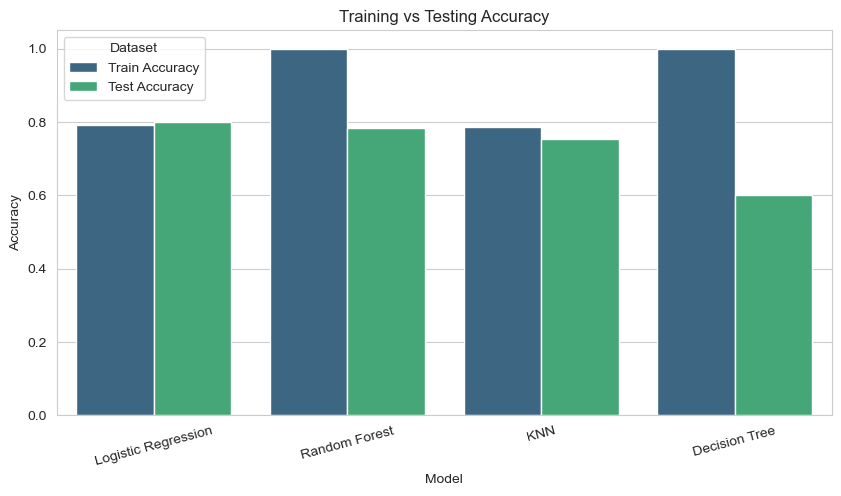

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df.melt(id_vars='Model', var_name='Dataset', value_name='Accuracy'),
            x='Model', y='Accuracy', hue='Dataset', palette='viridis')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.title('Training vs Testing Accuracy')
plt.show()

## Best Model Testing

In [12]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
print('Best Model:', best_model_name)
print('Test Accuracy:', round(accuracy_score(y_test, y_pred), 4))

Best Model: Logistic Regression
Test Accuracy: 0.8


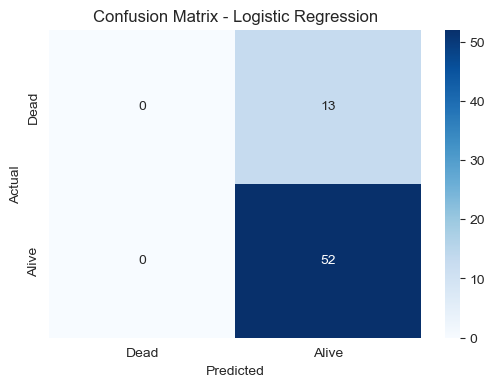

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [14]:
print(classification_report(y_test, y_pred, target_names=['Dead', 'Alive']))

              precision    recall  f1-score   support

        Dead       0.00      0.00      0.00        13
       Alive       0.80      1.00      0.89        52

    accuracy                           0.80        65
   macro avg       0.40      0.50      0.44        65
weighted avg       0.64      0.80      0.71        65



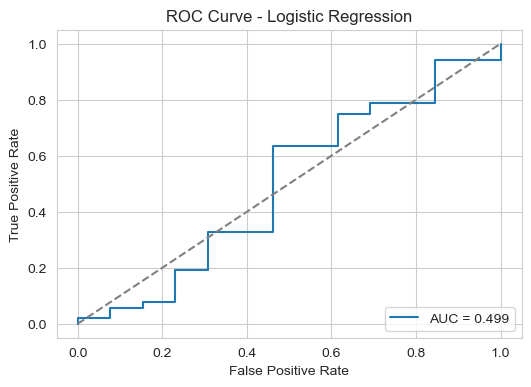

ROC-AUC Score: 0.4985


In [15]:
if hasattr(best_model.named_steps['model'], 'predict_proba'):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc='lower right')
    plt.show()

    print('ROC-AUC Score:', round(auc_score, 4))
else:
    print('ROC-AUC is not available for this model.')

## Save Best Model

In [16]:
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'breast_cancer_best_model.pkl'
joblib.dump(best_model, model_path)
print(f'Model saved to: {model_path}')

Model saved to: artifacts\breast_cancer_best_model.pkl
